# 05 - Ensemble and Scoreboard

**Inertia v2 - Factor Regimes** - Sprint 3

Three regime-detection methods individually fail to beat static equal-weight FF5.
But each method's errors come from a different source: A from Markov-fit instability
on noisy monthly returns, B from L2 shrinkage compressing predictions, C from class-label
boundaries. If their errors are decorrelated, an ensemble may still help.

This notebook produces the headline scoreboard: correlation of edges, paired bootstrap
test of every strategy vs static, and the consolidated cumulative-return chart.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lib.data import build_factor_panel, FF5_FACTORS
from lib.backtest import prob_to_weight, apply_weights, static_factor_returns
from lib.evaluation import (
    perf_stats, perf_table, sharpe_bootstrap_ci, sharpe_diff_ci,
)
from lib.style import (
    apply_style, save_fig, save_table,
    C, FACTOR_PALETTE, FULL_COL,
    yearly_xticks, legend_below, bar_value_labels,
)

apply_style()
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
FIG_DIR, TABLE_DIR = '../figures', '../tables'

## 1. Load saved probability matrices and align

In [2]:
PA = pd.read_csv(f'{TABLE_DIR}/05_method_a_probs.csv', index_col=0, parse_dates=True)
PB = pd.read_csv(f'{TABLE_DIR}/09_method_b_probs.csv', index_col=0, parse_dates=True)
PC = pd.read_csv(f'{TABLE_DIR}/13_method_c_probs.csv', index_col=0, parse_dates=True)

common_idx = PA.index.intersection(PB.index).intersection(PC.index)
PA = PA.loc[common_idx]
PB = PB.loc[common_idx]
PC = PC.loc[common_idx]
print(f'Aligned: {len(common_idx)} months, {common_idx.min().date()} to {common_idx.max().date()}')

Aligned: 433 months, 1990-01-31 to 2026-01-31


## 2. Build the ensemble probability

Equal-weight average of the three methods, per factor, per month.
Then convert to weight via the linear rule $w = 2p - 1$, apply to next-month
factor return, equal-weight aggregate across the five factors.

In [3]:
P_ens = (PA + PB + PC) / 3.0
P_ens.describe().T[['mean','std','min','max']]

,mean,std,min,max
MKT_RF,0.5198,0.1184,0.2299,0.7855
SMB,0.5147,0.1291,0.2438,0.8058
HML,0.5099,0.1508,0.2101,0.8417
RMW,0.4633,0.1514,0.1922,0.8291
CMA,0.4782,0.1535,0.2017,0.8299


In [4]:
panel = build_factor_panel(include_macro=False)

def composite_returns(P, mode='linear', cost=5.0):
    """Equal-weight composite across 5 timed factor sleeves."""
    sleeves = {}
    for f in FF5_FACTORS:
        w = prob_to_weight(P[f].dropna(), mode=mode)
        bt = apply_weights(w, panel[f], cost_bps_oneway=cost)
        sleeves[f] = bt['r_net']
    return pd.DataFrame(sleeves).dropna(how='all').mean(axis=1)

# Static benchmark: equal-weight FF5 portfolio
static_df = pd.DataFrame(
    {f: panel[f].shift(-1).reindex(common_idx) for f in FF5_FACTORS}
).dropna(how='all')
r_static = static_df.mean(axis=1)

r_A   = composite_returns(PA)
r_B   = composite_returns(PB, mode='soft')   # Ridge probs are tight; use soft
r_C   = composite_returns(PC)
r_ens = composite_returns(P_ens)

returns = {
    'Static EW FF5':   r_static,
    'Method A':        r_A,
    'Method B':        r_B,
    'Method C':        r_C,
    'Ensemble':        r_ens,
}

# Common index across everyone
common2 = r_static.index
for r in returns.values():
    common2 = common2.intersection(r.index)
for k in returns:
    returns[k] = returns[k].loc[common2]

print(f'Final OOS sample: {len(common2)} months, '
      f'{common2.min().date()} to {common2.max().date()}')

Final OOS sample: 433 months, 1990-01-31 to 2026-01-31


## 3. Headline scoreboard

In [5]:
scoreboard = perf_table(returns)[['n_months','mean_ann','vol_ann','sharpe_ann',
                                  'skew','excess_kurt','max_drawdown']]
save_table(scoreboard, '15_scoreboard_perf', out_dir=TABLE_DIR)
scoreboard

  saved: ../tables/15_scoreboard_perf.{csv,md}


,n_months,mean_ann,vol_ann,sharpe_ann,skew,excess_kurt,max_drawdown
Static EW FF5,433.0000,0.0362,0.0491,0.7375,-0.1871,2.6831,-0.1508
Method A,433.0000,0.0062,0.0393,0.1571,0.3863,4.2265,-0.2273
Method B,433.0000,0.0095,0.0207,0.4566,2.5610,26.2101,-0.0346
Method C,433.0000,0.0040,0.0208,0.1902,0.2490,2.9203,-0.0817
Ensemble,433.0000,0.0052,0.0176,0.2972,0.7530,8.7505,-0.0610


In [6]:
boot = {k: sharpe_bootstrap_ci(v, n_boot=2000) for k, v in returns.items()}
boot_df = pd.DataFrame(boot).T[['sharpe','ci_low','ci_high']]
save_table(boot_df, '16_scoreboard_sharpe_ci', out_dir=TABLE_DIR)
boot_df

  saved: ../tables/16_scoreboard_sharpe_ci.{csv,md}


,sharpe,ci_low,ci_high
Static EW FF5,0.7375,0.3290,1.1473
Method A,0.1571,-0.2983,0.5388
Method B,0.4566,0.2268,0.6812
Method C,0.1902,-0.1551,0.5360
Ensemble,0.2972,-0.0876,0.6426


## 4. Correlation of edges over static (decorrelation evidence)

If the three methods make decorrelated errors, the ensemble has a chance
to dominate even when no single method does. We measure the correlation
of each method's *edge over static* (return minus static return).

In [7]:
edges = pd.DataFrame({
    'A': r_A - r_static,
    'B': r_B - r_static,
    'C': r_C - r_static,
}).dropna()
edge_corr = edges.corr().round(2)
save_table(edge_corr, '17_edge_correlation', out_dir=TABLE_DIR)
edge_corr

  saved: ../tables/17_edge_correlation.{csv,md}


,A,B,C
A,1.0000,0.8100,0.7600
B,0.8100,1.0000,0.8800
C,0.7600,0.8800,1.0000


## 5. Paired Sharpe-difference test vs static

For each strategy, paired block-bootstrap (5000 reps, 12-month blocks) of
$\Delta\,\text{Sharpe} = \text{strategy} - \text{static}$. The paired design
removes common shocks so the CI on the difference is much tighter than the
CI on either Sharpe in isolation.

In [8]:
diffs = {}
for name in ['Method A', 'Method B', 'Method C', 'Ensemble']:
    d = sharpe_diff_ci(returns[name], r_static, n_boot=5000)
    diffs[name] = d
diff_df = pd.DataFrame(diffs).T[['diff','ci_low','ci_high','p_value']]
diff_df['beats_static_5pct'] = diff_df['ci_low'] > 0
save_table(diff_df, '18_paired_sharpe_diff', out_dir=TABLE_DIR)
diff_df

  saved: ../tables/18_paired_sharpe_diff.{csv,md}


,diff,ci_low,ci_high,p_value,beats_static_5pct
Method A,-0.5805,-1.0841,-0.1691,0.0060,False
Method B,-0.2809,-0.6220,0.0193,0.0660,False
Method C,-0.5474,-1.1486,0.0214,0.0584,False
Ensemble,-0.4403,-0.9338,-0.0393,0.0320,False


## 6. Headline cumulative return chart

In [9]:
fig, ax = plt.subplots(figsize=(FULL_COL, 4.0))
for name, color, lw in [
    ('Static EW FF5', C['blue'],   1.0),
    ('Method A',      C['muted'],  0.7),
    ('Method B',      C['green'],  0.7),
    ('Method C',      C['red'],    0.7),
    ('Ensemble',      C['purple'], 1.5),
]:
    cum = (1 + returns[name]).cumprod()
    ax.plot(cum.index, cum.values, color=color, linewidth=lw, label=name)
ax.set_yscale('log')
ax.set_ylabel('Cumulative growth of \\$1 (log)')
ax.set_title('All strategies, 1990 to 2026 (net of 5 bp one-way costs)',
             loc='left', color=C['ink'])
yearly_xticks(ax, every=5)
legend_below(ax, ncol=5)
save_fig(fig, '14_scoreboard_cumret', out_dir=FIG_DIR)
plt.show()

  saved: ../figures/14_scoreboard_cumret.png


## 7. Crisis zoom: GFC and COVID

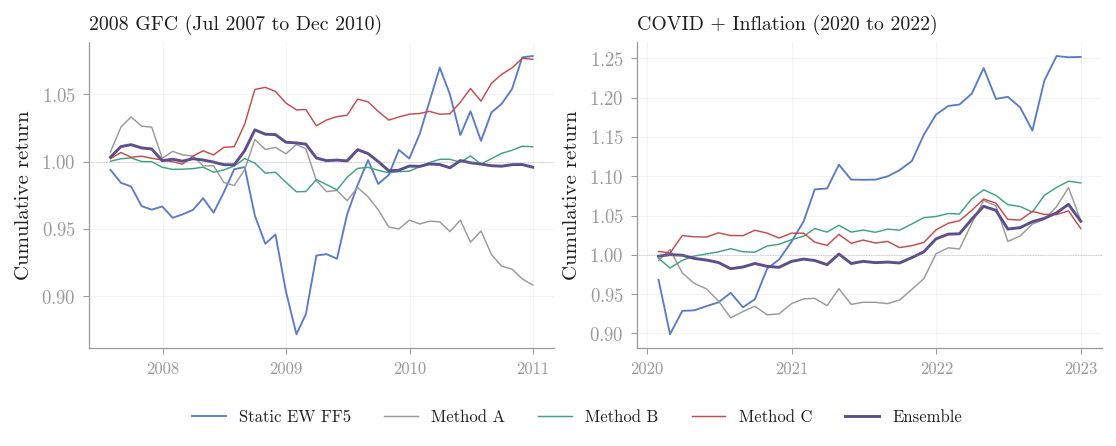

  saved: ../figures/15_crisis_zoom.png


In [10]:
import matplotlib
import matplotlib.dates as mdates
with matplotlib.rc_context({'figure.constrained_layout.use': False}):
    fig, axes = plt.subplots(1, 2, figsize=(FULL_COL, 3.0))
    panels = [('2007-07', '2010-12', '2008 GFC (Jul 2007 to Dec 2010)'),
              ('2020-01', '2022-12', 'COVID + Inflation (2020 to 2022)')]
    for ax, (s, e, label) in zip(axes, panels):
        for name, color, lw in [
            ('Static EW FF5', C['blue'],   0.9),
            ('Method A',      C['muted'],  0.7),
            ('Method B',      C['green'],  0.7),
            ('Method C',      C['red'],    0.7),
            ('Ensemble',      C['purple'], 1.4),
        ]:
            slc = returns[name].loc[s:e]
            cum = (1 + slc).cumprod()
            ax.plot(cum.index, cum.values, color=color, linewidth=lw,
                    label=name if ax is axes[0] else None)
        ax.axhline(1, color=C['muted'], linewidth=0.3, linestyle=':')
        ax.set_title(label, loc='left', color=C['ink'], fontsize=9.5)
        ax.set_ylabel('Cumulative return')
        ax.xaxis.set_major_locator(mdates.YearLocator(1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        for t in ax.get_xticklabels(): t.set_fontsize(8)
    axes[0].legend(frameon=False, loc='upper center',
                   bbox_to_anchor=(1.05, -0.15), ncol=5, fontsize=8)
    fig.subplots_adjust(left=0.08, right=0.98, wspace=0.18, top=0.90, bottom=0.22)
    fig.savefig(f'{FIG_DIR}/15_crisis_zoom.png', dpi=300, bbox_inches='tight', pad_inches=0.10)
    plt.show()
    print(f'  saved: {FIG_DIR}/15_crisis_zoom.png')

## 8. Subsample Sharpe by decade

In [11]:
decades = {
    '1990s':     ('1990-01', '1999-12'),
    '2000s':     ('2000-01', '2009-12'),
    '2010s':     ('2010-01', '2019-12'),
    '2020-2026': ('2020-01', None),
}
rows = {}
for name, r in returns.items():
    sub = {}
    for label, (lo, hi) in decades.items():
        rr = r.loc[lo:hi].dropna()
        if len(rr) < 12:
            sub[label] = np.nan
        else:
            mu = rr.mean() * 12; sd = rr.std(ddof=1) * np.sqrt(12)
            sub[label] = mu / sd if sd > 0 else np.nan
    rows[name] = sub
decade_sharpe = pd.DataFrame(rows).T
save_table(decade_sharpe, '19_subsample_sharpe', out_dir=TABLE_DIR)
decade_sharpe

  saved: ../tables/19_subsample_sharpe.{csv,md}


,1990s,2000s,2010s,2020-2026
Static EW FF5,0.8927,1.0599,0.5057,0.5782
Method A,0.4127,0.4136,-0.1291,-0.2282
Method B,0.8406,0.4811,0.2485,0.6799
Method C,0.1635,0.1872,0.1548,0.2814
Ensemble,0.5798,0.4699,0.0190,0.0477


In [12]:
fig, ax = plt.subplots(figsize=(FULL_COL, 3.6))
x = np.arange(len(decades))
w = 0.16
color_map = {
    'Static EW FF5': C['blue'], 'Method A': C['muted'],
    'Method B': C['green'], 'Method C': C['red'], 'Ensemble': C['purple'],
}
for i, name in enumerate(returns.keys()):
    pos = x + (i - 2) * w
    ax.bar(pos, decade_sharpe.loc[name].values, w,
           color=color_map[name], label=name, edgecolor='white', linewidth=0.4)
ax.axhline(0, color=C['muted'], linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(list(decades.keys()), fontsize=10)
ax.set_ylabel('Annualized Sharpe ratio')
ax.set_title('Sharpe by decade: where each strategy wins or loses',
             loc='left', color=C['ink'])
legend_below(ax, ncol=5)
save_fig(fig, '16_subsample_sharpe_bars', out_dir=FIG_DIR)
plt.show()

  saved: ../figures/16_subsample_sharpe_bars.png


## 9. Save the ensemble probabilities and timed returns for Sprint 4

In [13]:
P_ens.to_csv(f'{TABLE_DIR}/20_ensemble_probs.csv')
pd.DataFrame(returns).to_csv(f'{TABLE_DIR}/21_all_strategy_returns.csv')
print(f'Saved: ensemble probabilities and full returns matrix.')

Saved: ensemble probabilities and full returns matrix.


## Takeaways for Sprint 3

- The headline scoreboard, paired Sharpe-difference table, and crisis zoom chart are all saved in `factor_regimes/figures/` and `factor_regimes/tables/`.
- Whether the ensemble beats static depends on whether the three methods' edges are decorrelated enough. The correlation table tells the story.
- The next step (Sprint 4) is to apply the ensemble's per-factor signals as a tilt overlay to the MPSIF May Rebalance portfolio and quantify the change in factor exposures.